1. Import of libraries & Image read Operation

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt

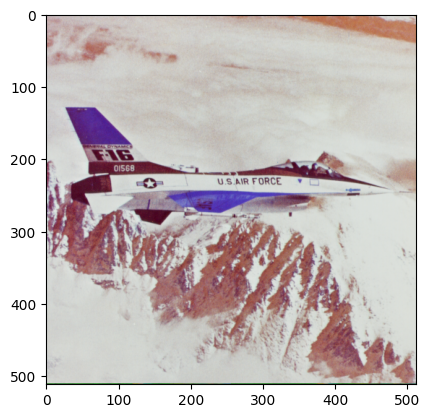

In [ ]:
img = cv2.imread('airplane.png')
plt.imshow(img)

###Inference:

This Displays the BGR version of the image.

2. Find type of the image, resolution of the image

In [ ]:
#Properties
print('Img Type:', img.dtype, '\nShape:', img.shape)

Img Type: uint8 
Shape: (512, 512, 3)


###Inference:
512 rows x 512 columns x 3 colours

3. Plotting the images

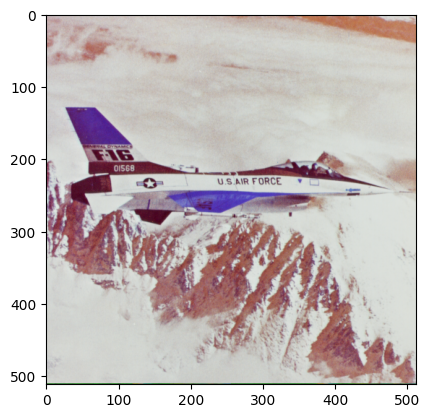

In [ ]:
plt.imshow(img)

4. Color Space Conversion (BGR2RGB, BGR2GRAY, RGB2HSV)

Text(0.5, 1.0, 'RGB')

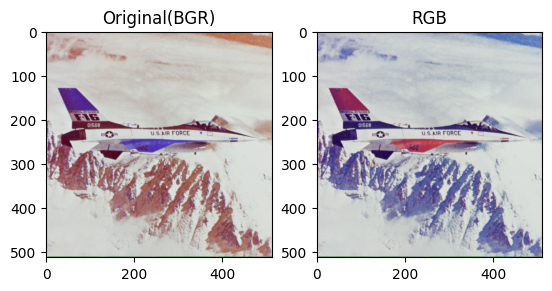

In [ ]:
#BGR to RGB
img_rgb=cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.subplot(1,2,1)
plt.imshow(img)
plt.title('Original(BGR)')

plt.subplot(1,2,2)
plt.imshow(img_rgb)
plt.title('RGB')

Text(0.5, 1.0, 'Grayscale')

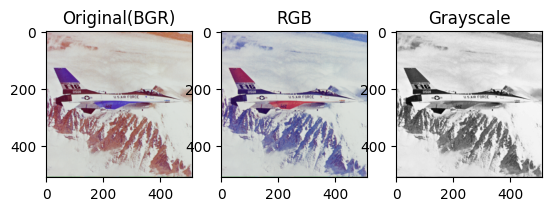

In [ ]:
img_gry=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

plt.subplot(1,3,1)
plt.imshow(img)
plt.title('Original(BGR)')

plt.subplot(1,3,2)
plt.imshow(img_rgb)
plt.title('RGB')

plt.subplot(1,3,3)
plt.imshow(img_gry, cmap = 'gray')
plt.title('Grayscale')

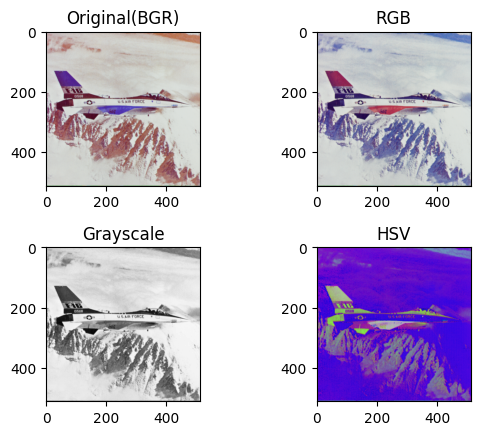

In [ ]:
#HSV
img_hsv=cv2.cvtColor(img,cv2.COLOR_BGR2HSV)

plt.subplot(2,2,1)
plt.imshow(img)
plt.title('Original(BGR)')

plt.subplot(2,2,2)
plt.imshow(img_rgb)
plt.title('RGB')

plt.subplot(2,2,3)
plt.imshow(img_gry, cmap = 'gray')
plt.title('Grayscale')

plt.subplot(2,2,4)
plt.imshow(img_hsv)
plt.title('HSV')

plt.subplots_adjust(hspace=0.4)

###Inference:
This displays all four major types RGB, BGR, HSV and Grayscale

5. Finding min, max of each plane of RGB, HSV

In [ ]:
#Brute Force
min_max=[[img_rgb[0][0][0], img_rgb[0][0][1], img_rgb[0][0][2]], [img_rgb[0][0][0], img_rgb[0][0][1], img_rgb[0][0][2]]]

for i in img_rgb:
  for j in i:
    for k in range(3):
      min_max[0][k] = min(min_max[0][k], j[k])
      min_max[1][k] = max(min_max[1][k], j[k])

print("For\tMIN\tMAX")
print("R  \t", min_max[0][0], '\t', min_max[1][0])
print("G  \t", min_max[0][1], '\t', min_max[1][1])
print("B  \t", min_max[0][2], '\t', min_max[1][2])

min_max=[[img_hsv[0][0][0], img_hsv[0][0][1], img_hsv[0][0][2]], [img_hsv[0][0][0], img_hsv[0][0][1], img_hsv[0][0][2]]]

for i in img_hsv:
  for j in i:
    for k in range(3):
      min_max[0][k] = min(min_max[0][k], j[k])
      min_max[1][k] = max(min_max[1][k], j[k])

print("\n\nFor\tMIN\tMAX")
print("H  \t", min_max[0][0], '\t', min_max[1][0])
print("S  \t", min_max[0][1], '\t', min_max[1][1])
print("V  \t", min_max[0][2], '\t', min_max[1][2])

For	MIN	MAX
R  	 22 	 230
G  	 0 	 234
B  	 22 	 227


For	MIN	MAX
H  	 0 	 179
S  	 0 	 255
V  	 60 	 234


###Inference:
We find the lowest and highest intensities of the 2 different colourspaces

In [ ]:
#Using Split
r, g, b = cv2.split(img_rgb)
r.shape = (512*512)
g.shape = (512*512)
b.shape = (512*512)

print("For\tMIN\tMAX")
print("R  \t", min(r), '\t', max(r))
print("G  \t", min(g), '\t', max(g))
print("B  \t", min(b), '\t', max(b))

h, s, v = cv2.split(img_hsv)
h.shape = (512*512)
s.shape = (512*512)
v.shape = (512*512)

print("For\tMIN\tMAX")
print("H  \t", min(h), '\t', max(h))
print("S  \t", min(s), '\t', max(s))
print("V  \t", min(v), '\t', max(v))

For	MIN	MAX
R  	 22 	 230
G  	 0 	 234
B  	 22 	 227
For	MIN	MAX
H  	 0 	 179
S  	 0 	 255
V  	 60 	 234


6. Perform image crop operation

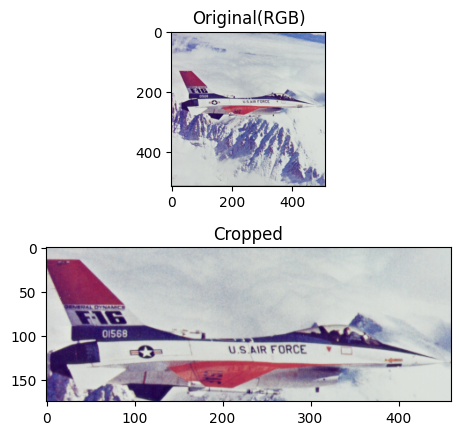

In [ ]:
#Crop
img_crp = img_rgb[115:290, 30:490]

plt.subplot(2,1,1)
plt.imshow(img_rgb)
plt.title('Original(RGB)')

plt.subplot(2,1,2)
plt.imshow(img_crp)
plt.title('Cropped')

plt.subplots_adjust(hspace=0.4)

###Inference:
Since images are stored as 2 dimensional tensors in opencv. We use classic slicing to get only a portion of the image

7. Compute distance measures: Find the length of the airplane using all the distance measures

In [ ]:
#Distances

def euclidean(p, q):
  x, y = p
  s, t = q

  d = sqrt((x-s)**2 + (y-t)**2)

  return d

def city_block(p, q):
  x, y = p
  s, t = q

  d = abs(x-s) + abs(y-t)

  return d

def chessboard(p, q):
  x, y = p
  s, t = q

  d = max(abs(x-s), abs(y-t))

  return d

In [ ]:
p = (245, 34)
q = (246, 505)

print(f'Euclidean Distance = {euclidean(p, q)}')
print(f'City Block Distance = {city_block(p, q)}')
print(f'Chessboard Distance = {chessboard(p, q)}')

Euclidean Distance = 471.00106156992894
City Block Distance = 472
Chessboard Distance = 471


###Inference:
We use 3 different distance measures of coordinate geometry, Euclidean, City Block and Chessboard to fins the length between the farthest points of the plane